In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

data=pd.read_csv(r"C:\Users\theyc\OneDrive\Desktop\employe.csv")
print(data)

       satisfactoryLevel  lastEvaluation  numberOfProjects  avgMonthlyHours  \
0                   0.38            0.53                 2              157   
1                   0.80            0.86                 5              262   
2                   0.11            0.88                 7              272   
3                   0.37            0.52                 2              159   
4                   0.41            0.50                 2              153   
...                  ...             ...               ...              ...   
14994               0.11            0.85                 7              275   
14995               0.99            0.83                 4              274   
14996               0.72            0.72                 4              175   
14997               0.24            0.91                 5              177   
14998               0.77            0.83                 6              271   

       timeSpent.company  workAccident  left  promo

In [6]:
print(data.head(10))

   satisfactoryLevel  lastEvaluation  numberOfProjects  avgMonthlyHours  \
0               0.38            0.53                 2              157   
1               0.80            0.86                 5              262   
2               0.11            0.88                 7              272   
3               0.37            0.52                 2              159   
4               0.41            0.50                 2              153   
5               0.10            0.77                 6              247   
6               0.92            0.85                 5              259   
7               0.42            0.53                 2              142   
8               0.45            0.54                 2              135   
9               0.11            0.81                 6              305   

   timeSpent.company  workAccident  left  promotionInLast5years   dept  salary  
0                  3             0     1                      0  sales     low  
1           

In [8]:
print(data.columns)

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='str')


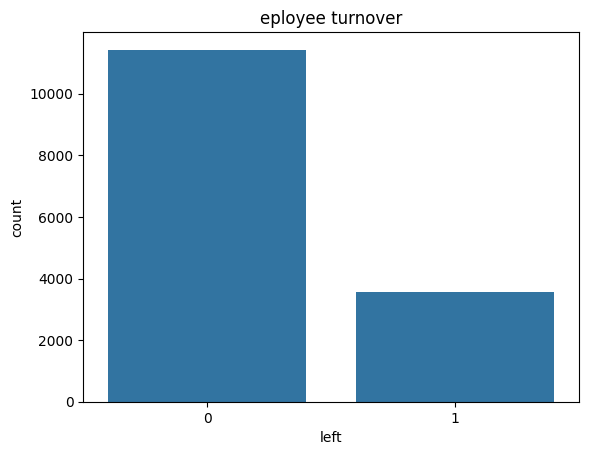

In [4]:
#ANALYSIS WITH VISUALIZATION

#A CHART FOR EMPLOYEEE TURNOVER

sb.countplot(x="left",data=data)
plt.title("eployee turnover")
plt.show()

In [6]:
# The different values inside the number of project col

data['numberOfProjects'].unique()

array([2, 5, 7, 6, 4, 3])

In [7]:
 #along with the unique values we also get the count that how many people are working on how many projects
data['numberOfProjects'].value_counts()
 

numberOfProjects
4    4365
3    4055
5    2761
2    2388
6    1174
7     256
Name: count, dtype: int64

## Target column - left


In [10]:
data['left'].unique()

array([1, 0])

## CLEAN THE DATASET

In [11]:
# check the null values in the data

data.isnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(3008)

In [14]:
data.drop_duplicates(inplace = True)

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.shape

(11991, 10)

In [25]:
#FILTER THE EMPLOYEES WHO GOT PROMOTED BUT STILL LEFT
df1 = data[(data["promotionInLast5years"] == 1) & (data["left"] == 1)]

In [26]:
print(df1)

       satisfactoryLevel  lastEvaluation  numberOfProjects  avgMonthlyHours  \
52                  0.79            0.59                 4              139   
189                 0.11            0.79                 6              292   
386                 0.41            0.56                 2              154   
1131                0.44            0.55                 2              128   
7980                0.45            0.51                 2              160   
8085                0.41            0.46                 2              160   
8469                0.46            0.45                 2              138   
14530               0.87            1.00                 4              258   

       timeSpent.company  workAccident  left  promotionInLast5years  \
52                     3             0     1                      1   
189                    4             0     1                      1   
386                    3             0     1                      1   
1131

## ANALYSIS WITH VISUALIZATION

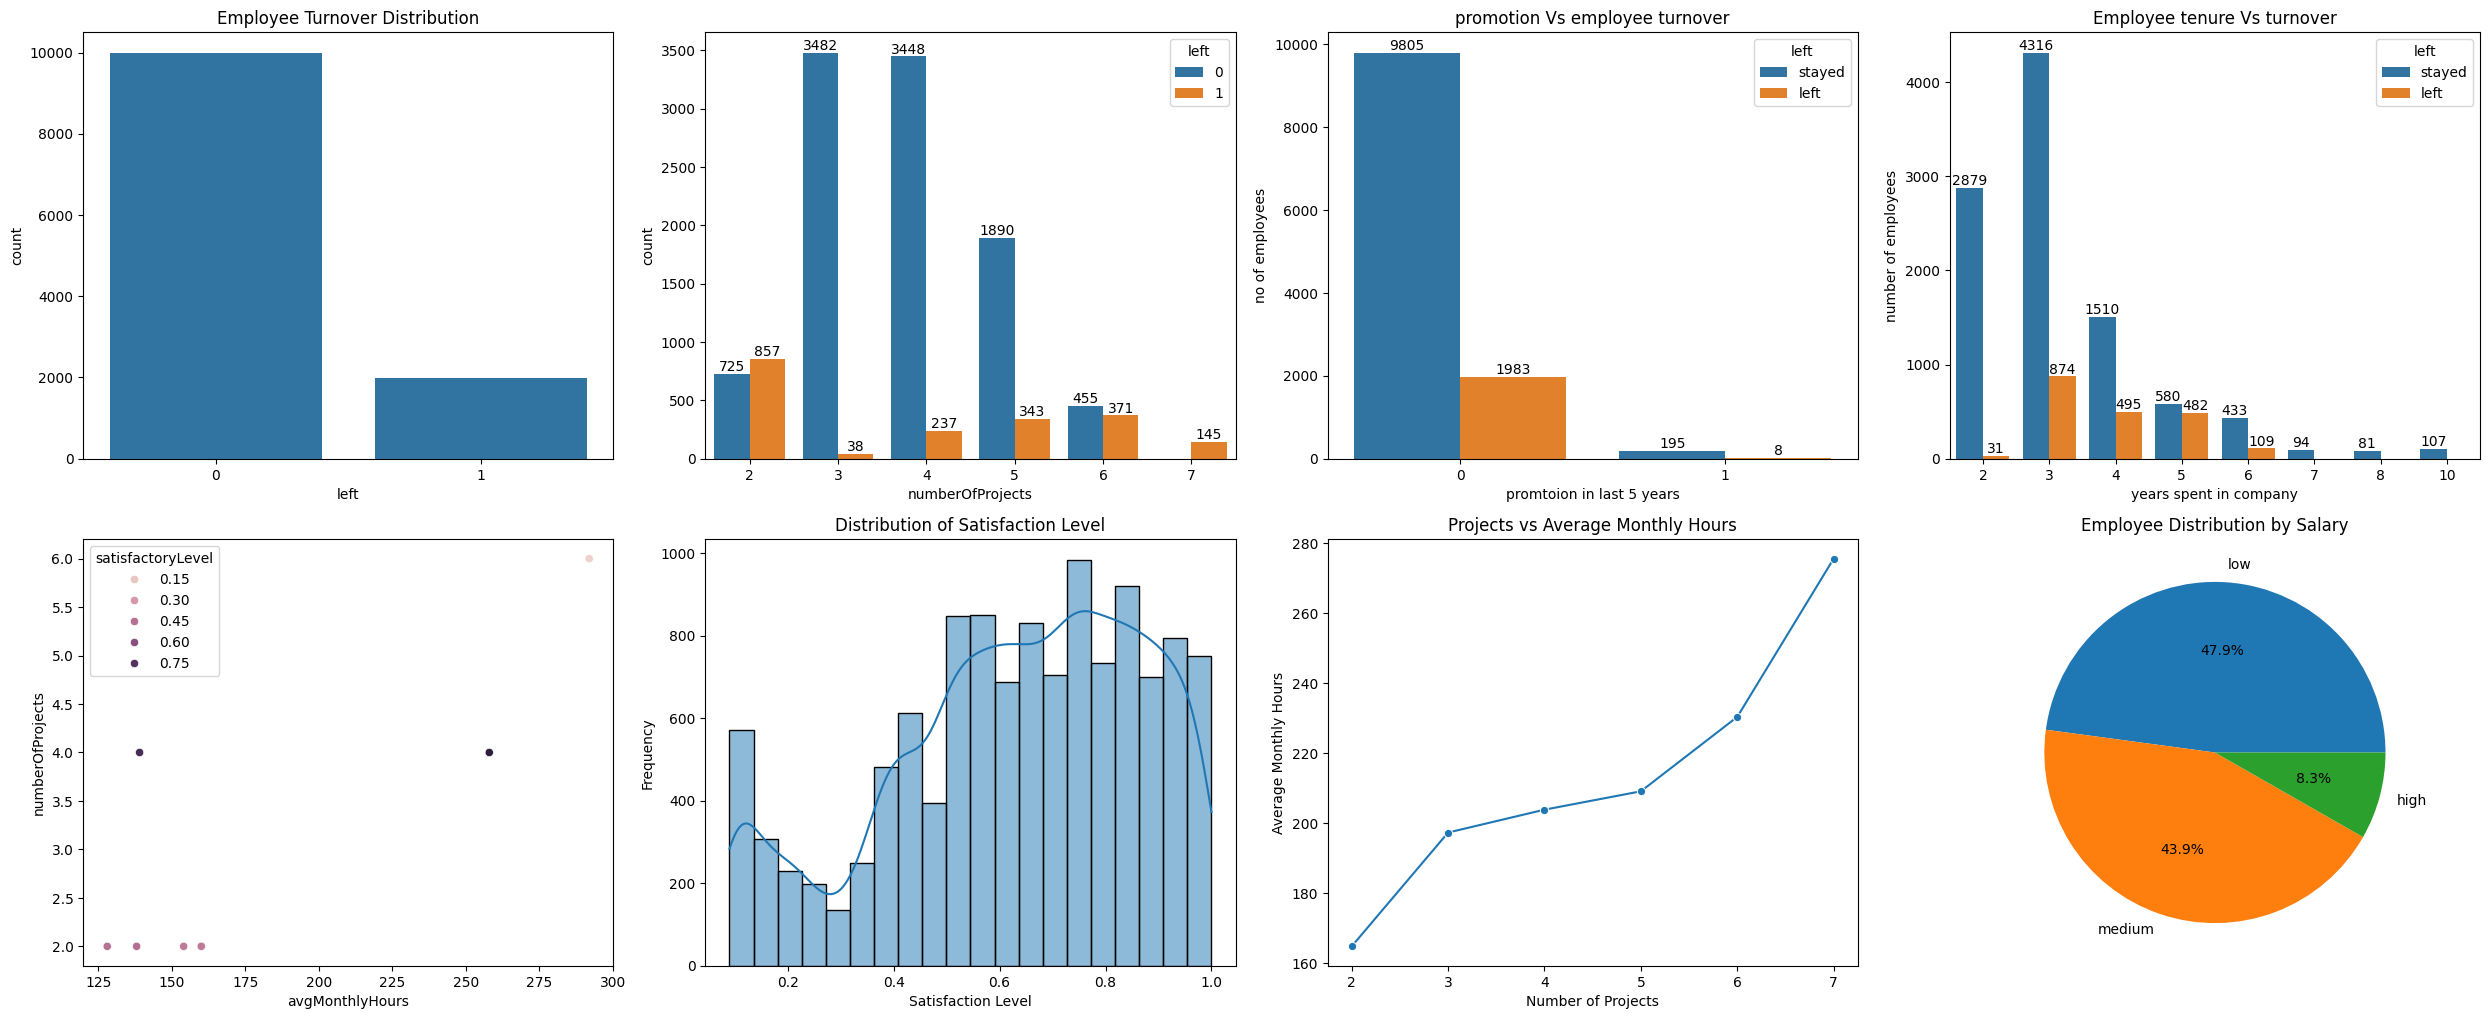

In [ ]:
plt.figure(figsize=(25,20))


#GRAPH1 : DISTRIBUTION OF EMPLOYEE TURNOVER

plt.subplot(4,4,1)
sb.countplot(x="left",data=data)
plt.title("Employee Turnover Distribution")

#CONCLUSION: Majority of employees stayed (~10,000) vs those who left (~2,000)




#GRAPH2 : EFFECT OF NUMBER OF PROJECTS ON EMPLOYEE ATTRITION

plt.subplot(4,4,2)
x1 = sb.countplot(x="numberOfProjects",data=data,hue="left")
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])

#CONCLUSION:Employees with 4 projects are the most common and mostly stayed
#Employees with 2 projects have high leaving rate — possibly underutilized
#Employees with 6-7 projects also leave — possibly overworked




#GRAPH3 : RELATIONSHIP BETWEEN PROMOTION AND EMPLOYEE TURNOVERS

plt.subplot(4,4,3)
x2=sb.countplot(x="promotionInLast5years", hue="left", data=data)
x2.bar_label(x2.containers[0])
x2.bar_label(x2.containers[1])
plt.xlabel("promtoion in last 5 years")
plt.ylabel("no of employees")
plt.title("promotion Vs employee turnover")
plt.legend(title="left",labels=["stayed","left"])

#CONCLUSION:9,805 employees received no promotion and mostly stayed
#1,983 employees left without receiving a promotion




#GRAPH4: RELATIONSHIP OF THE TENURE AND EMPLOYEE TURNOVER

plt.subplot(4,4,4)
x3=sb.countplot(x="timeSpent.company",hue="left",data=data)
x3.bar_label(x3.containers[0])
x3.bar_label(x3.containers[1])
plt.title("Employee tenure Vs turnover")
plt.xlabel("years spent in company")
plt.ylabel("number of employees")
plt.legend(title="left",labels=["stayed","left"])

#CONCLUSION:Employees leaving most at 3-4 years of tenure
#Very new employees (2 years) mostly stay
#Employees who cross 5+ years tend to stay long-term




#GRAPH5: SATISFACTORY LEVELS , NO. OF PROJECTS ,AVERAGE MONTHLY HOURS

plt.subplot(4,4,5)
sb.scatterplot(x="avgMonthlyHours",y="numberOfProjects",data=df1,hue="satisfactoryLevel")
#CONCLUSION:Employees with low satisfaction (0.15–0.30) tend to work on fewer projects with irregular hours




#GRAPH 6: HISTOGRAM OF SATISFACTION LEVEL

plt.subplot(4,4,6)
sb.histplot(data["satisfactoryLevel"], bins=20, kde=True)
plt.title("Distribution of Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Frequency")

#CONCLUSION:Distribution is not normal — has multiple peaks
#Large group of employees with very low satisfaction (~0.1)
#Another cluster around 0.6–0.8 (moderately satisfied)




#GRAPH 7: LINE PLOT - AVERAGE MONTHLY HOURS BY NUMBER OF PROJECTS

plt.subplot(4,4,7)

line_data = data.groupby("numberOfProjects")["avgMonthlyHours"].mean().reset_index()

sb.lineplot(
    x="numberOfProjects",
    y="avgMonthlyHours",
    data=line_data,
    marker="o"
)

plt.title("Projects vs Average Monthly Hours")
plt.xlabel("Number of Projects")
plt.ylabel("Average Monthly Hours")

#CONCLUSION:Clear positive correlation — more projects = more hours worked
#Employees with 6-7 projects work significantly more hours
#This explains why high-project employees burn out and leave




#GRAPH 8: Salary-WISE EMPLOYEE DISTRIBUTION :

plt.subplot(4,4,8)

salary = data["salary"].value_counts()

plt.pie(
    salary,
    labels=salary.index,
    autopct="%1.1f%%"
)

plt.title("Employee Distribution by Salary")

#CONCLUSION:Majority of employees earn low to medium salaries
#Very few are in the high salary bracket

plt.tight_layout()
plt.show()